In [1]:
#farida
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")


In [3]:
df.shape

(5110, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

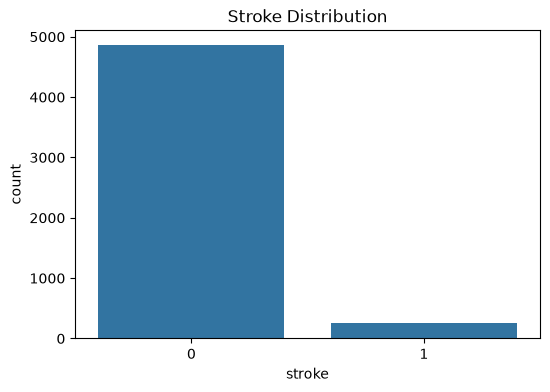

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title('Stroke Distribution')
plt.show()

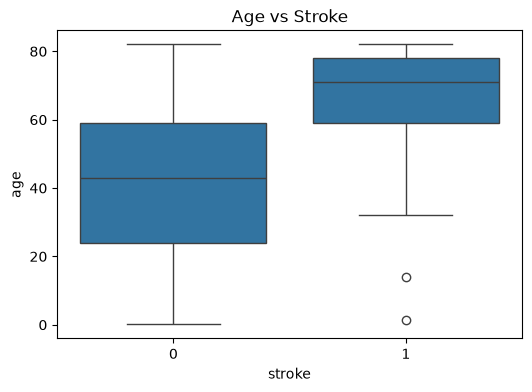

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x='stroke', y='age', data=df)
plt.title('Age vs Stroke')
plt.show()

In [11]:
#gana
df= df.drop("id", axis=1)
df = df[df["gender"] != "Other"]

In [12]:
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 60, 100], labels=['young', 'middle', 'senior'])
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['underweight', 'normal', 'overweight', 'obese'])
df['bmi_category'] = df['bmi_category'].cat.add_categories('Missing').fillna('Missing')
df['risk_combo'] = df['hypertension'] + df['heart_disease']
df['avg_glucose_level'] = np.log1p(df['avg_glucose_level'])

In [13]:
df = pd.get_dummies(
    df,
    columns=["gender", "ever_married", "work_type", "Residence_type", "smoking_status", "age_group", "bmi_category"],
    drop_first=True
)

df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,risk_combo,gender_Male,ever_married_Yes,work_type_Never_worked,...,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age_group_middle,age_group_senior,bmi_category_normal,bmi_category_overweight,bmi_category_obese,bmi_category_Missing
0,67.0,0,1,5.436731,36.6,1,1,True,True,False,...,True,True,False,False,False,True,False,False,True,False
1,61.0,0,0,5.314240,NaN,1,0,False,True,False,...,False,False,True,False,False,True,False,False,False,True
2,80.0,0,1,4.672081,32.5,1,1,True,True,False,...,False,False,True,False,False,True,False,False,True,False
3,49.0,0,0,5.148831,34.4,1,0,False,True,False,...,True,False,False,True,True,False,False,False,True,False
4,79.0,1,0,5.165471,24.0,1,1,False,True,False,...,False,False,True,False,False,True,True,False,False,False


In [14]:

x = df.drop("stroke", axis=1)
y = df["stroke"]

In [33]:
import joblib
features = x.columns.tolist()
joblib.dump(features,"features.pkl")

['features.pkl']

In [15]:
x_train_full, x_test, y_train_full, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

In [16]:
median_bmi = x_train["bmi"].median()
for d in (x_train, x_val, x_test):
    d["bmi"] = d["bmi"].fillna(median_bmi)
    d["bmi"] = d["bmi"].clip(upper=60)
    d["bmi"] = np.log1p(d["bmi"])

In [17]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [34]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [18]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos   

smote = SMOTE(sampling_strategy=0.5, random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print(f"Shape of x_train after SMOTE: {x_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")
print(f"Class distribution of y_train after SMOTE:\n{y_train_resampled.value_counts()}")

Shape of x_train after SMOTE: (4665, 22)
Shape of y_train after SMOTE: (4665,)
Class distribution of y_train after SMOTE:
stroke
0    3110
1    1555
Name: count, dtype: int64


In [19]:
def find_best_threshold(model, x_val, y_val):
    
    val_prob = model.predict_proba(x_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx]

from sklearn.metrics import precision_recall_curve

In [20]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg.fit(x_train_resampled, y_train_resampled)

best_thr_lr = find_best_threshold(log_reg, x_val, y_val)
y_prob_lr = log_reg.predict_proba(x_test)[:, 1]
y_pred_lr = (y_prob_lr >= best_thr_lr).astype(int)
print("Tuned threshold:", best_thr_lr)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print(f"Logistic Regression Accuracy Score:{accuracy_score(y_test, y_pred_lr):.4f}")

Tuned threshold: 0.7234462109297021
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.93       972
           1       0.19      0.54      0.28        50

    accuracy                           0.86      1022
   macro avg       0.58      0.71      0.60      1022
weighted avg       0.94      0.86      0.89      1022

Logistic Regression Confusion Matrix:
[[857 115]
 [ 23  27]]
Logistic Regression Accuracy Score:0.8650


In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(x_train_resampled, y_train_resampled)

best_thr_knn = find_best_threshold(knn, x_val, y_val)
y_prob_knn = knn.predict_proba(x_test)[:, 1]
y_pred_knn = (y_prob_knn >= best_thr_knn).astype(int)
print("Tuned threshold:", best_thr_knn)

print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print(f"KNN Accuracy Score: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN ROC AUC Score: {roc_auc_score(y_test, y_prob_knn):.4f}")

Tuned threshold: 0.42704964229539344
KNN Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       972
           1       0.11      0.28      0.15        50

    accuracy                           0.85      1022
   macro avg       0.53      0.58      0.54      1022
weighted avg       0.92      0.85      0.88      1022

KNN Confusion Matrix:
[[854 118]
 [ 36  14]]
KNN Accuracy Score: 0.8493
KNN ROC AUC Score: 0.6420


In [22]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
decision_tree.fit(x_train_resampled, y_train_resampled)

best_thr_dt = find_best_threshold(decision_tree, x_val, y_val)
y_prob_dt = decision_tree.predict_proba(x_test)[:, 1]
y_pred_dt = (y_prob_dt >= best_thr_dt).astype(int)
print("Tuned threshold:", best_thr_dt)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print(f"Decision Tree Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree ROC AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

Tuned threshold: 1.0
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       972
           1       0.12      0.18      0.15        50

    accuracy                           0.90      1022
   macro avg       0.54      0.56      0.54      1022
weighted avg       0.92      0.90      0.91      1022

Decision Tree Confusion Matrix:
[[907  65]
 [ 41   9]]
Decision Tree Accuracy Score: 0.8963
Decision Tree ROC AUC Score: 0.5566


In [23]:
#salma
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

In [24]:
random_forest = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
random_forest.fit(x_train_resampled, y_train_resampled)

best_thr_rf = find_best_threshold(random_forest, x_val, y_val)
y_prob_rf = random_forest.predict_proba(x_test)[:, 1]
y_pred_rf = (y_prob_rf >= best_thr_rf).astype(int)
print("Tuned threshold:", best_thr_rf)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print(f"Random Forest Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest ROC AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

Tuned threshold: 0.17
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       972
           1       0.14      0.46      0.21        50

    accuracy                           0.83      1022
   macro avg       0.55      0.66      0.56      1022
weighted avg       0.93      0.83      0.87      1022

Random Forest Confusion Matrix:
[[828 144]
 [ 27  23]]
Random Forest Accuracy Score: 0.8327
Random Forest ROC AUC Score: 0.7766


In [35]:
import joblib

joblib.dump(random_forest, "stroke_model.pkl")

['stroke_model.pkl']

In [25]:
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_model.fit(x_train_resampled, y_train_resampled)

best_thr_svm = find_best_threshold(svm_model, x_val, y_val)
y_prob_svm = svm_model.predict_proba(x_test)[:, 1]
y_pred_svm = (y_prob_svm >= best_thr_svm).astype(int)
print("Tuned threshold:", best_thr_svm)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print(f"SVM Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"SVM ROC AUC Score: {roc_auc_score(y_test, y_prob_svm):.4f}")

Tuned threshold: 0.14594259833194667
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89       972
           1       0.12      0.44      0.18        50

    accuracy                           0.81      1022
   macro avg       0.54      0.63      0.54      1022
weighted avg       0.92      0.81      0.86      1022

SVM Confusion Matrix:
[[806 166]
 [ 28  22]]
SVM Accuracy Score: 0.8102
SVM ROC AUC Score: 0.7776


In [26]:
ada_boost = AdaBoostClassifier(n_estimators=200, random_state=42)
ada_boost.fit(x_train_resampled, y_train_resampled)

best_thr_ada = find_best_threshold(ada_boost, x_val, y_val)
y_prob_ada = ada_boost.predict_proba(x_test)[:, 1]
y_pred_ada = (y_prob_ada >= best_thr_ada).astype(int)
print("Tuned threshold:", best_thr_ada)

print("AdaBoost Classification Report:")
print(classification_report(y_test, y_pred_ada))

print("AdaBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

print(f"AdaBoost Accuracy Score: {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"AdaBoost ROC AUC Score: {roc_auc_score(y_test, y_prob_ada):.4f}")

Tuned threshold: 0.4756393768216419
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       972
           1       0.14      0.62      0.23        50

    accuracy                           0.80      1022
   macro avg       0.56      0.72      0.56      1022
weighted avg       0.94      0.80      0.85      1022

AdaBoost Confusion Matrix:
[[788 184]
 [ 19  31]]
AdaBoost Accuracy Score: 0.8014
AdaBoost ROC AUC Score: 0.8105


In [27]:
gradient_boosting = GradientBoostingClassifier(n_estimators=200, random_state=42)
gradient_boosting.fit(x_train_resampled, y_train_resampled)

best_thr_gb = find_best_threshold(gradient_boosting, x_val, y_val)
y_prob_gb = gradient_boosting.predict_proba(x_test)[:, 1]
y_pred_gb = (y_prob_gb >= best_thr_gb).astype(int)
print("Tuned threshold:", best_thr_gb)

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print(f"Gradient Boosting Accuracy Score: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Gradient Boosting ROC AUC Score: {roc_auc_score(y_test, y_prob_gb):.4f}")

Tuned threshold: 0.09220513400090007
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       972
           1       0.13      0.70      0.21        50

    accuracy                           0.75      1022
   macro avg       0.55      0.72      0.53      1022
weighted avg       0.94      0.75      0.82      1022

Gradient Boosting Confusion Matrix:
[[728 244]
 [ 15  35]]
Gradient Boosting Accuracy Score: 0.7466
Gradient Boosting ROC AUC Score: 0.8074


In [28]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(x_train_resampled, y_train_resampled)

best_thr_xgb = find_best_threshold(xgb_model, x_val, y_val)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= best_thr_xgb).astype(int)
print("Tuned threshold:", best_thr_xgb)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print(f"XGBoost Accuracy Score: {accuracy_score(y_test,y_pred_xgb):.4f}")
print(f"XGBoost ROC AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Tuned threshold: 0.024639558
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.13      0.52      0.21        50

    accuracy                           0.81      1022
   macro avg       0.55      0.67      0.55      1022
weighted avg       0.93      0.81      0.86      1022

XGBoost Confusion Matrix:
[[798 174]
 [ 24  26]]
XGBoost Accuracy Score: 0.8063
XGBoost ROC AUC Score: 0.7569


In [29]:
from imblearn.pipeline import Pipeline as ImbPipeline
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_for_cv = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
}

cv_results = {}
for name, base_model in models_for_cv.items():
    pipeline = ImbPipeline([
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("model", base_model)
])
    scores = cross_val_score(pipeline, x_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} -> Mean ROC AUC: {scores.mean():.4f} | Std: {scores.std():.4f}")

Logistic Regression  -> Mean ROC AUC: 0.8331 | Std: 0.0311
KNN                  -> Mean ROC AUC: 0.6845 | Std: 0.0159
Decision Tree        -> Mean ROC AUC: 0.5641 | Std: 0.0326
Random Forest        -> Mean ROC AUC: 0.8046 | Std: 0.0185
SVM                  -> Mean ROC AUC: 0.7479 | Std: 0.0168
AdaBoost             -> Mean ROC AUC: 0.8175 | Std: 0.0225
Gradient Boosting    -> Mean ROC AUC: 0.8034 | Std: 0.0311
XGBoost              -> Mean ROC AUC: 0.7956 | Std: 0.0301


In [30]:
test_auc_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "AdaBoost": accuracy_score(y_test, y_pred_ada),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "XGBoost": accuracy_score(y_test, y_pred_xgb),
}

test_roc_scores = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_lr),
    "KNN": roc_auc_score(y_test, y_prob_knn),
    "Decision Tree": roc_auc_score(y_test, y_prob_dt),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "SVM": roc_auc_score(y_test, y_prob_svm),
    "AdaBoost": roc_auc_score(y_test, y_prob_ada),
    "Gradient Boosting": roc_auc_score(y_test, y_prob_gb),
    "XGBoost": roc_auc_score(y_test, y_prob_xgb),
}

comparison_df = pd.DataFrame({
    "Model": list(test_auc_scores.keys()),
    "Test Accuracy": list(test_auc_scores.values()),
    "Test ROC AUC": [test_roc_scores[m] for m in test_auc_scores.keys()],
    "CV Mean ROC AUC": [cv_results[m].mean() for m in test_auc_scores.keys()],
    "CV Std ROC AUC": [cv_results[m].std() for m in test_auc_scores.keys()],
}).sort_values("Test ROC AUC", ascending=False).reset_index(drop=True)

comparison_df

,Model,Test Accuracy,Test ROC AUC,CV Mean ROC AUC,CV Std ROC AUC
0,Logistic Regression,0.864971,0.828683,0.833128,0.031124
1,AdaBoost,0.801370,0.810545,0.817519,0.022529
2,Gradient Boosting,0.746575,0.807366,0.803378,0.031136
3,SVM,0.810176,0.777634,0.747938,0.016770
4,Random Forest,0.832681,0.776605,0.804586,0.018528
5,XGBoost,0.806262,0.756893,0.795599,0.030056
6,KNN,0.849315,0.641965,0.684527,0.015950
7,Decision Tree,0.896282,0.556564,0.564140,0.032635


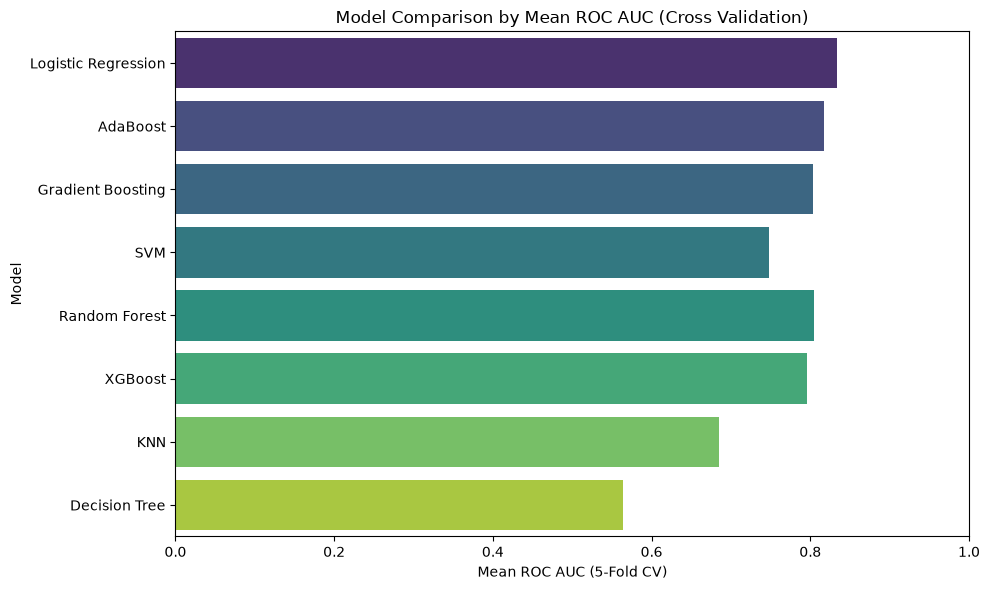

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_df,
    x="CV Mean ROC AUC",
    y="Model",
    palette="viridis"
)
plt.title("Model Comparison by Mean ROC AUC (Cross Validation)")
plt.xlabel("Mean ROC AUC (5-Fold CV)")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

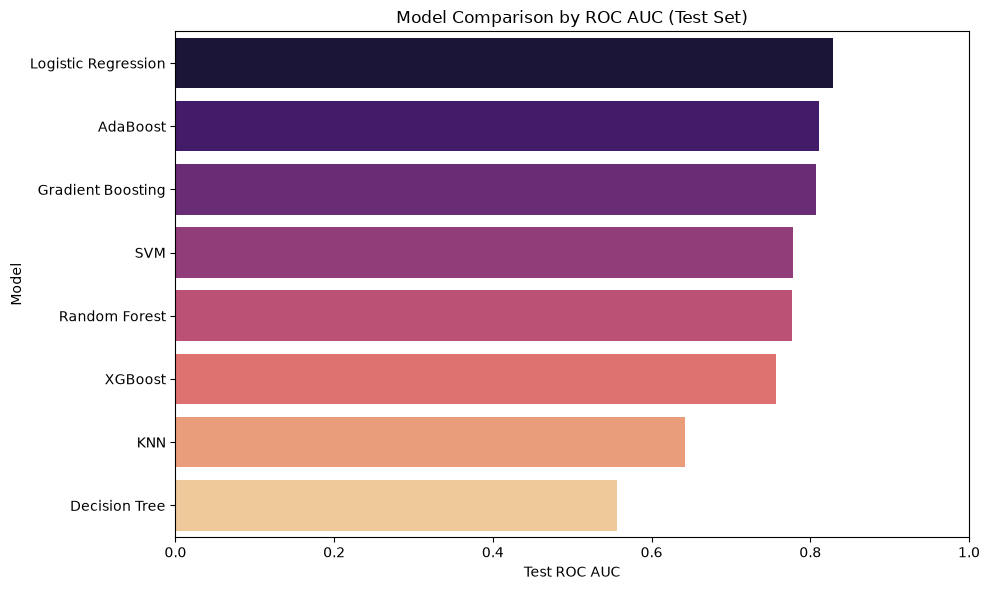

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_df.sort_values("Test ROC AUC", ascending=False),
    x="Test ROC AUC",
    y="Model",
    palette="magma"
)
plt.title("Model Comparison by ROC AUC (Test Set)")
plt.xlabel("Test ROC AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()